In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/gait-data-processing/labels_train_set.csv
/kaggle/input/competitions/gait-data-processing/test_set.npy
/kaggle/input/competitions/gait-data-processing/train_set.csv


# 🦿 EEG Gait Decoding — Spinal Cord Injury & Lokomat

**Objectif :** Prédire le signal IMU (angle articulaire) à partir de signaux EEG chez des patients avec lésion médullaire complète  
**Dataset :** [Kaggle — EEG Gait Decoding Challenge](https://www.kaggle.com/competitions/gait-data-processing)  
**Auteur :** Nicolas (9Nicox)  
**Date :** 2026

---

## Contexte clinique

Les exosquelettes robotiques (Lokomat, Ekso, ReWalk) permettent aux patients avec lésion médullaire (SCI) de retrouver une mobilité assistée. L'intégration de l'**intention motrice** détectée par EEG dans la boucle de contrôle de ces dispositifs représente le prochain saut technologique : passer d'un exosquelette qui *impose* un mouvement à un exosquelette qui *anticipe* l'intention du patient.

Ce notebook explore la faisabilité de ce décodage en temps réel à partir de données EEG de patients SCI marchant sous assistance Lokomat — une population clinique directement comparable à celle traitée par les systèmes NeuroRestore (EPFL).

### La question centrale

> *Un modèle de prédiction d'angle articulaire à partir d'EEG est-il suffisamment précis **et** suffisamment rapide pour piloter un exosquelette en temps réel ?*


### Différences clés avec un projet BCI standard

| Dimension | Projet standard | Ce projet |
|-----------|----------------|----------|
| Population | Sujets neurotypiques | Patients SCI |
| Tâche | Classification (événements discrets) | **Régression (signal continu)** |
| Signal cible | Label binaire | Angle articulaire (°) |
| Métrique | AUC ROC | RMSE, corrélation de Pearson, R² |
| Application | Prothèse de main | **Exosquelette de marche** |

---

## Structure du notebook
1. [Setup & Imports](#1-setup)
2. [Exploration du dataset](#2-exploration)
3. [Preprocessing du signal EEG](#3-preprocessing)
4. [Feature Extraction](#4-features)
5. [Modélisation — Régression](#5-regression)
6. [Benchmark Temps-Réel](#6-benchmark)
7. [Validation inter-sessions (LOSO)](#7-loso)
8. [Discussion & Applicabilité Clinique](#8-discussion)

---
## 1. Setup & Imports <a id='1-setup'></a>

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────────
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── Signal processing ──────────────────────────────────────────────────────────
from scipy import signal
from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import pearsonr

# ── Machine Learning ───────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

# ── Config visuelle ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = plt.cm.tab10.colors
sns.set_palette('tab10')

# ── Constantes dataset ─────────────────────────────────────────────────────────
FS_EEG   = 512          # Fréquence d'échantillonnage EEG (Hz)
FS_IMU   = 20           # Fréquence originale IMU (Hz) — resamplé à 512 Hz
N_CHANNELS = 16         # Canaux EEG
N_SUBJECTS = 2          # Patients SCI

EEG_CHANNELS = ['FP1','FP2','F3','F4','FC1','FC2','C4','C3',
                 'Cz','CP2','CP1','P4','Pz','P3','O2','O1']

# ── Chemins ────────────────────────────────────────────────────────────────────
DATA_DIR = '/kaggle/input/competitions/gait-data-processing'
"""TRAIN_DATA   = '/kaggle/input/gait-data-processing/train_set.csv'
TRAIN_LABELS = '/kaggle/input/gait-data-processing/labels_train_set.csv'
TEST_DATA    = '/kaggle/input/gait-data-processing/test_set.npy'"""

TRAIN_DATA = os.path.join(DATA_DIR, 'train_set.csv')
TRAIN_LABELS = os.path.join(DATA_DIR, 'train_labels.csv')
TEST_DATA  = os.path.join(DATA_DIR, 'test_set.npy')

print(f"Setup OK")
print(f"EEG : {FS_EEG} Hz | {N_CHANNELS} canaux | {N_SUBJECTS} patients SCI")
print(f"IMU : {FS_IMU} Hz originale → resamplé à {FS_EEG} Hz")

Setup OK
EEG : 512 Hz | 16 canaux | 2 patients SCI
IMU : 20 Hz originale → resamplé à 512 Hz


---
## 2. Exploration du dataset <a id='2-exploration'></a>

In [3]:
# ── Chargement des données ─────────────────────────────────────────────────────
print("Chargement du dataset...")
df_train  = pd.read_csv('/kaggle/input/competitions/gait-data-processing/train_set.csv')
df_labels = pd.read_csv('/kaggle/input/competitions/gait-data-processing/labels_train_set.csv')

print(f"\nTrain EEG  : {df_train.shape}")
print(f"Labels IMU : {df_labels.shape}")
print(f"\nColonnes train :")
print(df_train.columns.tolist())
print(f"\nColonnes labels :")
print(df_labels.columns.tolist())
print(f"\nAperçu train :")
df_train.head()

Chargement du dataset...

Train EEG  : (3048430, 20)
Labels IMU : (3048430, 3)

Colonnes train :
['ID', 'Subject', 'Session', 'Time:512Hz', 'FP1', 'FP2', 'F3', 'F4', 'FC1', 'FC2', 'C4', 'C3', 'Cz', 'CP2', 'CP1', 'P4', 'Pz', 'P3', 'O2', 'O1']

Colonnes labels :
['ID', 'time', 'angle']

Aperçu train :


,ID,Subject,Session,Time:512Hz,FP1,FP2,F3,F4,FC1,FC2,C4,C3,Cz,CP2,CP1,P4,Pz,P3,O2,O1
0,0,SCI2,1,0.000000,-15006.495117,760.498108,-14070.362305,-1148.193481,-9447.022461,-16526.857422,-15436.719727,-11457.569336,-12786.866211,-10324.366211,-104514664.0,-23172.169922,-1313.183716,-14525.928711,-22304.298828,-20537.404297
1,1,SCI2,1,0.001953,-15006.446289,750.927795,-14067.481445,-1145.996216,-9448.047852,-16520.363281,-15425.391602,-11451.905273,-12781.006836,-10316.358398,-104514664.0,-23159.816406,-1312.304810,-14525.098633,-22321.095703,-20543.654297
2,2,SCI2,1,0.003906,-15025.928711,746.826233,-14080.225586,-1126.318481,-9455.274414,-16515.675781,-15428.370117,-11451.807617,-12785.254883,-10325.147461,-104514680.0,-23177.687500,-1317.431763,-14528.809570,-22313.722656,-20539.796875
3,3,SCI2,1,0.005859,-15005.372070,768.261780,-14069.483398,-1135.888794,-9457.618164,-16527.052734,-15437.012695,-11467.139648,-12792.481445,-10331.153320,-104514656.0,-23187.550781,-1326.904419,-14546.680664,-22341.408203,-20583.449219
4,4,SCI2,1,0.007812,-15004.834961,764.160217,-14071.338867,-1146.728638,-9451.661133,-16524.074219,-15428.858398,-11476.807617,-12793.311523,-10327.881836,-104514648.0,-23174.171875,-1325.390747,-14547.071289,-22339.552734,-20578.468750


In [4]:
print(f"\nAperçu labels :")
df_labels.head()


Aperçu labels :


,ID,time,angle
0,0,0.000000,1.057401
1,1,0.001953,1.075232
2,2,0.003906,1.089365
3,3,0.005859,1.099761
4,4,0.007812,1.106410


In [5]:
# ── Structure par sujet et session ────────────────────────────────────────────
print("=" * 55)
print("STRUCTURE DU DATASET")
print("=" * 55)

for subj in df_train['Subject'].unique():
    df_subj = df_train[df_train['Subject'] == subj]
    sessions = df_subj['Session'].unique()
    n_samples = len(df_subj)
    duration_min = n_samples / FS_EEG / 60
    print(f"\nSujet {subj}")
    print(f"  Sessions    : {sorted(sessions)}")
    print(f"  Samples     : {n_samples:,}")
    print(f"  Durée totale: {duration_min:.1f} min")

STRUCTURE DU DATASET

Sujet SCI2
  Sessions    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
  Samples     : 1,844,596
  Durée totale: 60.0 min

Sujet SCI3
  Sessions    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(10), np.int64(13), np.int64(14)]
  Samples     : 1,203,834
  Durée totale: 39.2 min


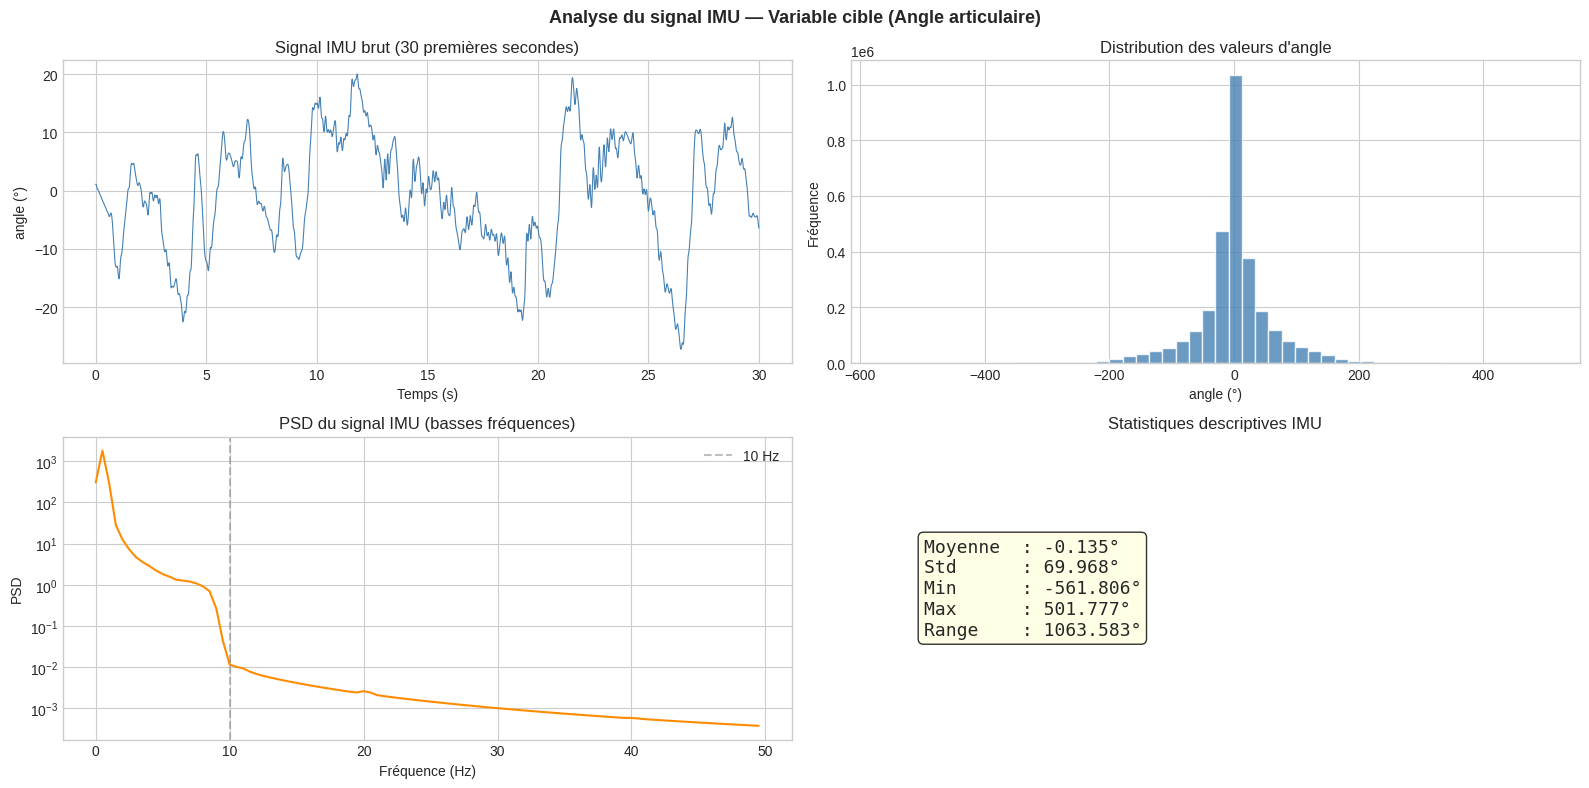

In [6]:
# ── Analyse du signal IMU (variable cible) ────────────────────────────────────
imu_signal = df_labels['angle'].values

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Analyse du signal IMU — Variable cible (Angle articulaire)', 
             fontweight='bold', fontsize=13)

# Signal temporel — 30 premières secondes
t = np.arange(len(imu_signal)) / FS_EEG
mask_30s = t <= 30
axes[0,0].plot(t[mask_30s], imu_signal[mask_30s], color='steelblue', lw=0.8)
axes[0,0].set_title('Signal IMU brut (30 premières secondes)')
axes[0,0].set_xlabel('Temps (s)')
axes[0,0].set_ylabel('angle (°)')

# Distribution
axes[0,1].hist(imu_signal, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Distribution des valeurs d\'angle')
axes[0,1].set_xlabel('angle (°)')
axes[0,1].set_ylabel('Fréquence')

# PSD du signal IMU
freqs, psd = signal.welch(imu_signal, fs=FS_EEG, nperseg=FS_EEG*2)
axes[1,0].semilogy(freqs[:100], psd[:100], color='darkorange', lw=1.5)
axes[1,0].set_title('PSD du signal IMU (basses fréquences)')
axes[1,0].set_xlabel('Fréquence (Hz)')
axes[1,0].set_ylabel('PSD')
axes[1,0].axvline(10, ls='--', color='gray', alpha=0.5, label='10 Hz')
axes[1,0].legend()

# Stats descriptives
stats_text = (
    f"Moyenne  : {imu_signal.mean():.3f}°\n"
    f"Std      : {imu_signal.std():.3f}°\n"
    f"Min      : {imu_signal.min():.3f}°\n"
    f"Max      : {imu_signal.max():.3f}°\n"
    f"Range    : {imu_signal.max() - imu_signal.min():.3f}°"
)
axes[1,1].text(0.1, 0.5, stats_text, transform=axes[1,1].transAxes,
               fontsize=13, fontfamily='monospace',
               verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1,1].set_title('Statistiques descriptives IMU')
axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('imu_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# 1. Vérifier les valeurs aberrantes
print(f"Valeurs > 100° : {(np.abs(df_labels['angle']) > 100).sum()}")
print(f"Valeurs > 200° : {(np.abs(df_labels['angle']) > 200).sum()}")

# 2. Vérifier si les valeurs aberrantes sont concentrées 
#    dans certaines sessions
df_labels_merged = df_labels.copy()
df_labels_merged['Subject'] = df_train['Subject'].values
df_labels_merged['Session'] = df_train['Session'].values

for subj in ['SCI2', 'SCI3']:
    for sess in df_train[df_train['Subject'] == subj]['Session'].unique():
        mask = (df_labels_merged['Subject'] == subj) & \
               (df_labels_merged['Session'] == sess)
        vals = df_labels_merged[mask]['angle']
        if vals.abs().max() > 100:
            print(f"  {subj} Session {sess} : max={vals.abs().max():.1f}°")

Valeurs > 100° : 365010
Valeurs > 200° : 69535
  SCI2 Session 4 : max=214.7°
  SCI2 Session 5 : max=244.5°
  SCI2 Session 6 : max=215.9°
  SCI2 Session 10 : max=116.4°
  SCI3 Session 1 : max=144.8°
  SCI3 Session 2 : max=105.8°
  SCI3 Session 3 : max=106.7°
  SCI3 Session 4 : max=189.0°
  SCI3 Session 5 : max=190.4°
  SCI3 Session 7 : max=206.3°
  SCI3 Session 10 : max=113.5°
  SCI3 Session 13 : max=551.3°
  SCI3 Session 14 : max=561.8°


---
## 2.1 — Contrôle qualité du signal IMU

### Problème identifié

L'analyse exploratoire révèle des valeurs d'angle articulaire physiologiquement 
impossibles dans plusieurs sessions :

| Sujet | Sessions affectées | Valeur max observée | Seuil physiologique |
|-------|-------------------|--------------------|--------------------|
| SCI2  | 4, 5, 6, 10       | 244.5°             | ~60-80° (genou)    |
| SCI3  | Toutes            | 561.8°             | ~60-80° (genou)    |

L'amplitude normale du mouvement de genou lors de la marche assistée 
est de ~40-60°. Des valeurs à 244° ou 561° sont mécaniquement impossibles 
et résultent très probablement d'artefacts de resynchronisation lors du 
resampling du signal IMU (20 Hz → 512 Hz).

### Solutions envisagées

**Option envisagée — Suppression des lignes aberrantes (>±50°)**  
Supprimer individuellement les échantillons dont la valeur d'angle dépasse 
un seuil physiologique est plus rigoureux que les remplacer par interpolation.  
Cependant, cette approche est insuffisante pour les sessions les plus dégradées 
(SCI3 Sessions 13-14, SCI3 Session 7) : si 20-30% d'une session est supprimé, 
les fenêtres glissantes qui chevauchent ces zones produiront des features 
corrompues même après nettoyage du signal cible.

**Option retenue — Exclusion des sessions dégradées**  
On conserve uniquement les sessions dont le signal IMU est physiologiquement 
cohérent sur l'intégralité de la durée :

- **SCI2** : Sessions 1, 2, 3, 7, 8, 9, 11, 12, 13, 14, 15 (11 sessions ✅)
- **SCI3** : Exclue de l'analyse principale (toutes les sessions présentent 
  des artefacts)

### Impact sur l'analyse

La perte de SCI3 réduit le dataset à un seul sujet exploitable. 
C'est une **limite majeure** documentée de ce travail : avec un seul sujet, 
aucune généralisation inter-individuelle n'est possible. Les résultats 
sont valides en tant qu'étude de cas clinique (SCI2) mais ne peuvent 
pas être extrapolés à la population SCI en général.


## Filtre sur SCI2 seulement

In [8]:
# ── Filtrage qualité — SCI2 sessions propres uniquement ───────────────────────
# Justification : Section 2.1 — contrôle qualité du signal IMU
CLEAN_SESSIONS_SCI2 = [1, 2, 3, 7, 8, 9, 11, 12, 13, 14, 15]
SUBJECT_ANALYSIS    = 'SCI2'

mask = (df_train['Subject'] == SUBJECT_ANALYSIS) & \
       (df_train['Session'].isin(CLEAN_SESSIONS_SCI2))

df_train  = df_train[mask].reset_index(drop=True)
df_labels = df_labels[mask].reset_index(drop=True)

print(f"Dataset filtré :")
print(f"  Sujet    : {SUBJECT_ANALYSIS}")
print(f"  Sessions : {CLEAN_SESSIONS_SCI2}")
print(f"  Samples  : {len(df_train):,}")
print(f"  Durée    : {len(df_train)/FS_EEG/60:.1f} min")
print(f"\nVérification angle max : {df_labels['angle'].abs().max():.1f}°")
if df_labels['angle'].abs().max() <= 100:
    print("  ✅ Signal IMU physiologiquement cohérent")
else:
    print("  ⚠️  Valeurs aberrantes encore présentes")

Dataset filtré :
  Sujet    : SCI2
  Sessions : [1, 2, 3, 7, 8, 9, 11, 12, 13, 14, 15]
  Samples  : 1,414,004
  Durée    : 46.0 min

Vérification angle max : 80.1°
  ✅ Signal IMU physiologiquement cohérent


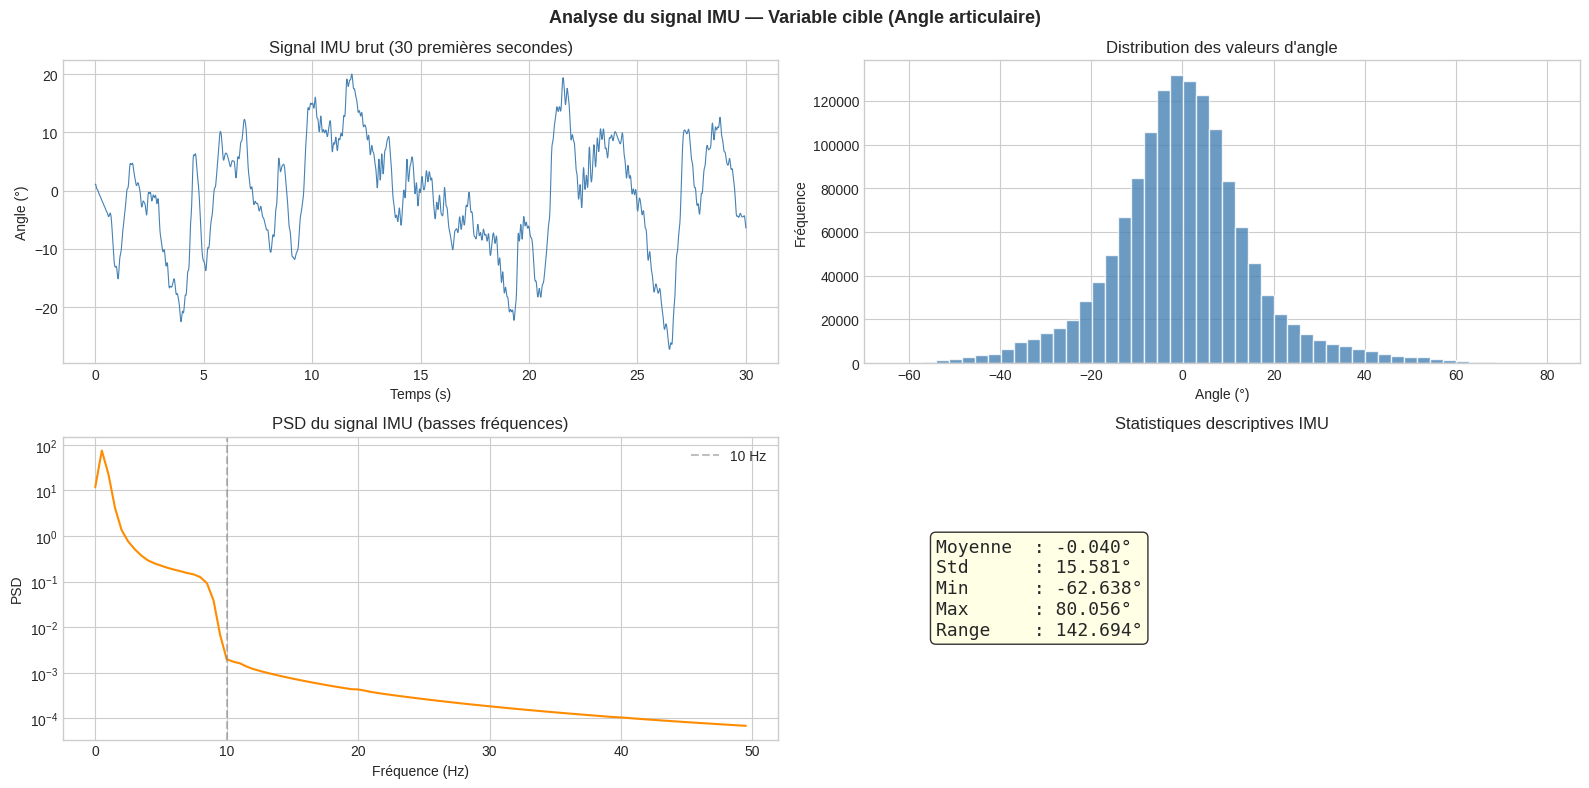

In [9]:
# ── Analyse du signal IMU (variable cible) ────────────────────────────────────
imu_signal = df_labels['angle'].values

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Analyse du signal IMU — Variable cible (Angle articulaire)', 
             fontweight='bold', fontsize=13)

# Signal temporel — 30 premières secondes
t = np.arange(len(imu_signal)) / FS_EEG
mask_30s = t <= 30
axes[0,0].plot(t[mask_30s], imu_signal[mask_30s], color='steelblue', lw=0.8)
axes[0,0].set_title('Signal IMU brut (30 premières secondes)')
axes[0,0].set_xlabel('Temps (s)')
axes[0,0].set_ylabel('Angle (°)')

# Distribution
axes[0,1].hist(imu_signal, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Distribution des valeurs d\'angle')
axes[0,1].set_xlabel('Angle (°)')
axes[0,1].set_ylabel('Fréquence')

# PSD du signal IMU
freqs, psd = signal.welch(imu_signal, fs=FS_EEG, nperseg=FS_EEG*2)
axes[1,0].semilogy(freqs[:100], psd[:100], color='darkorange', lw=1.5)
axes[1,0].set_title('PSD du signal IMU (basses fréquences)')
axes[1,0].set_xlabel('Fréquence (Hz)')
axes[1,0].set_ylabel('PSD')
axes[1,0].axvline(10, ls='--', color='gray', alpha=0.5, label='10 Hz')
axes[1,0].legend()

# Stats descriptives
stats_text = (
    f"Moyenne  : {imu_signal.mean():.3f}°\n"
    f"Std      : {imu_signal.std():.3f}°\n"
    f"Min      : {imu_signal.min():.3f}°\n"
    f"Max      : {imu_signal.max():.3f}°\n"
    f"Range    : {imu_signal.max() - imu_signal.min():.3f}°"
)
axes[1,1].text(0.1, 0.5, stats_text, transform=axes[1,1].transAxes,
               fontsize=13, fontfamily='monospace',
               verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1,1].set_title('Statistiques descriptives IMU')
axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('imu_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

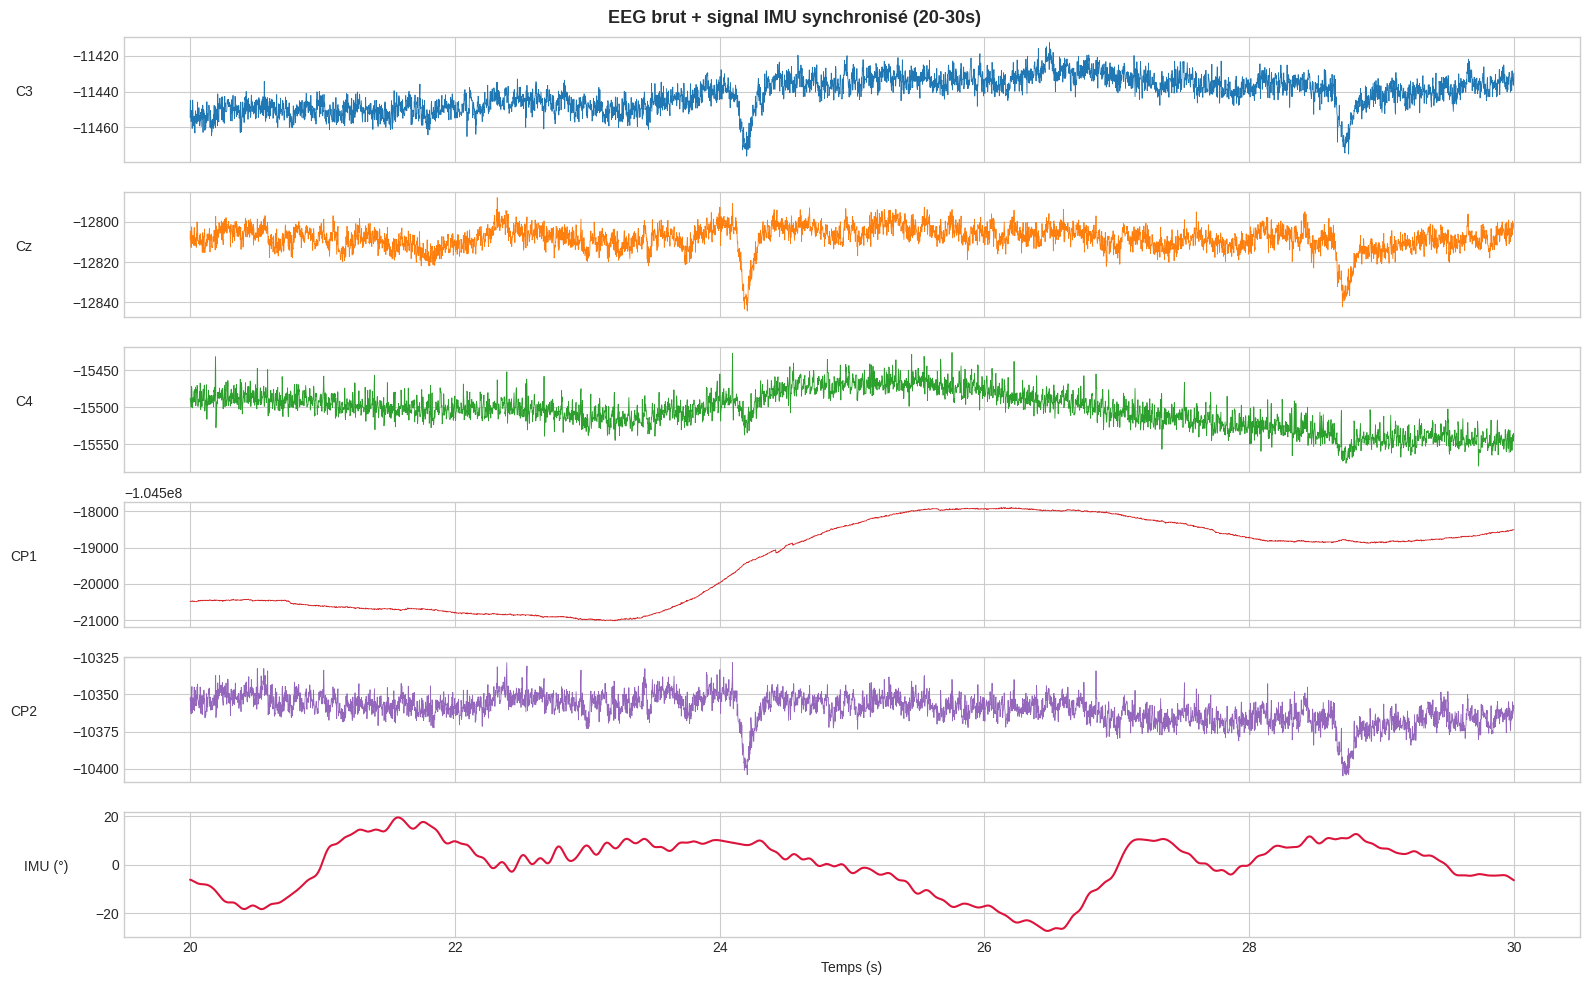

→ Observation la relation temporelle entre l'activité EEG et le signal IMU
→ Reherche des patterns EEG récurrents corrélés aux cycles de marche


In [10]:
# ── Visualisation EEG brut + IMU superposés ───────────────────────────────────
# Canaux moteurs et sensoriels d'intérêt pour la marche
GAIT_CHANNELS = ['C3', 'Cz', 'C4', 'CP1', 'CP2']
gait_idx = [EEG_CHANNELS.index(c) for c in GAIT_CHANNELS if c in EEG_CHANNELS]

X_eeg = df_train[EEG_CHANNELS].values
t_all = np.arange(len(X_eeg)) / FS_EEG

# Fenêtre 20-30s
mask = (t_all >= 20) & (t_all <= 30)

fig, axes = plt.subplots(len(GAIT_CHANNELS) + 1, 1, figsize=(16, 10), sharex=True)
fig.suptitle('EEG brut + signal IMU synchronisé (20-30s)', fontweight='bold', fontsize=13)

for i, (ch, idx) in enumerate(zip(GAIT_CHANNELS, gait_idx)):
    axes[i].plot(t_all[mask], X_eeg[mask, idx], color=COLORS[i], lw=0.6)
    axes[i].set_ylabel(ch, fontsize=10, rotation=0, labelpad=35)

axes[-1].plot(t_all[mask], imu_signal[mask], color='crimson', lw=1.5)
axes[-1].set_ylabel('IMU (°)', fontsize=10, rotation=0, labelpad=35)
axes[-1].set_xlabel('Temps (s)')

plt.tight_layout()
plt.savefig('eeg_imu_synchronized.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Observation la relation temporelle entre l'activité EEG et le signal IMU")
print("→ Reherche des patterns EEG récurrents corrélés aux cycles de marche")

In [11]:
# ── Corrélation EEG brut → IMU par canal ──────────────────────────────────────
# Première exploration : quel canal EEG est le plus corrélé au signal IMU ?
print("Corrélation de Pearson (EEG brut → signal IMU) :")
print("-" * 45)

correlations = []
for ch in EEG_CHANNELS:
    r, p = pearsonr(df_train[ch].values, imu_signal)
    correlations.append((ch, r, p))

correlations.sort(key=lambda x: abs(x[1]), reverse=True)
for ch, r, p in correlations:
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"  {ch:<5} : r = {r:+.4f}  {sig}")

print("\n→ Note : corrélation sur signal brut non filtré — valeur indicative seulement")
print("  Les features fréquentielles seront bien plus discriminantes")

Corrélation de Pearson (EEG brut → signal IMU) :
---------------------------------------------
  O2    : r = +0.0018  *
  Cz    : r = +0.0015  ns
  O1    : r = +0.0015  ns
  CP2   : r = +0.0014  ns
  C3    : r = +0.0013  ns
  FP2   : r = +0.0012  ns
  Pz    : r = +0.0012  ns
  P4    : r = +0.0011  ns
  FC1   : r = +0.0011  ns
  F3    : r = +0.0008  ns
  CP1   : r = +0.0007  ns
  FC2   : r = -0.0006  ns
  FP1   : r = +0.0004  ns
  F4    : r = +0.0004  ns
  C4    : r = +0.0003  ns
  P3    : r = -0.0002  ns

→ Note : corrélation sur signal brut non filtré — valeur indicative seulement
  Les features fréquentielles seront bien plus discriminantes


---
## 3. Preprocessing du signal EEG <a id='3-preprocessing'></a>

### Adaptations par rapport au projet Grasp-and-Lift

Le pipeline de base reste similaire (Notch → filtre → CAR → z-score), mais deux ajustements sont nécessaires :

1. **Fréquence d'échantillonnage** : 512 Hz — tous les paramètres de filtrage et de fenêtrage sont exprimés en fonction de cette valeur
2. **Stratégie de filtrage** : pour la marche, les bandes mu (8-12 Hz) et bêta (13-30 Hz) restent pertinentes, mais les **basses fréquences liées au cycle de marche** (~1-3 Hz) peuvent aussi être informatives — le cycle de marche normal est à ~1 Hz

> **Note clinique :** Chez les patients SCI, le signal EEG moteur est potentiellement plus bruité et moins stable que chez les sujets neurotypiques. La robustesse du preprocessing est donc particulièrement importante ici.

In [12]:
from scipy.signal import detrend

# ── Pipeline de preprocessing ──────────────────────────────────────────────────

def butter_bandpass(lowcut, highcut, fs=FS_EEG, order=5):
    nyq = 0.5 * fs
    return butter(order, [lowcut/nyq, highcut/nyq], btype='band')

def butter_lowpass(cutoff, fs=FS_EEG, order=5):
    nyq = 0.5 * fs
    return butter(order, cutoff/nyq, btype='low')

def notch_filter(X, freq=50, fs=FS_EEG, Q=30):
    """Suppression du bruit secteur (50 Hz)."""
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, X, axis=0)

def preprocess_eeg(X, strategy='bandpass_mu_beta'):
    """
    Pipeline de preprocessing EEG.
    Stratégies :
      - 'bandpass_mu_beta' : 8-30 Hz
      - 'lowpass_gait'     : < 3 Hz  (cycle de marche ~1 Hz)
      - 'broadband'        : 1-40 Hz (large bande)
    """
    X_proc = X.copy().astype(np.float64)

    # 0. Détrending — supprime la dérive DC linéaire par canal
    X_proc = detrend(X_proc, axis=0)
    
    # 1. CAR (Common Average Reference) en premier — supprime la dérive DC
    X_proc = X_proc - X_proc.mean(axis=1, keepdims=True)
    
    # 2. Notch 50 Hz
    X_proc = notch_filter(X_proc)
    
    # 3. Filtrage fréquentiel
    if strategy == 'bandpass_mu_beta':
        b, a = butter_bandpass(8, 30)
        X_proc = filtfilt(b, a, X_proc, axis=0)
    elif strategy == 'lowpass_gait':
        b, a = butter_lowpass(3)
        X_proc = filtfilt(b, a, X_proc, axis=0)
    elif strategy == 'broadband':
        b, a = butter_bandpass(1, 40)
        X_proc = filtfilt(b, a, X_proc, axis=0)

    # 4. Z-score par canal
    X_proc = (X_proc - X_proc.mean(axis=0)) / (X_proc.std(axis=0) + 1e-8)

    return X_proc


# ── Application et validation ──────────────────────────────────────────────────
X_raw = df_train[EEG_CHANNELS].values

X_mb   = preprocess_eeg(X_raw, strategy='bandpass_mu_beta')
X_gait = preprocess_eeg(X_raw, strategy='lowpass_gait')
X_bb   = preprocess_eeg(X_raw, strategy='broadband')

print("Preprocessing OK")
for name, X in [('mu+beta', X_mb), ('gait <3Hz', X_gait), ('broadband', X_bb)]:
    print(f"  {name:<15} : mean={X.mean():.4f} | std={X.std():.4f}")

Preprocessing OK
  mu+beta         : mean=0.0000 | std=1.0000
  gait <3Hz       : mean=-0.0000 | std=1.0000
  broadband       : mean=0.0000 | std=1.0000


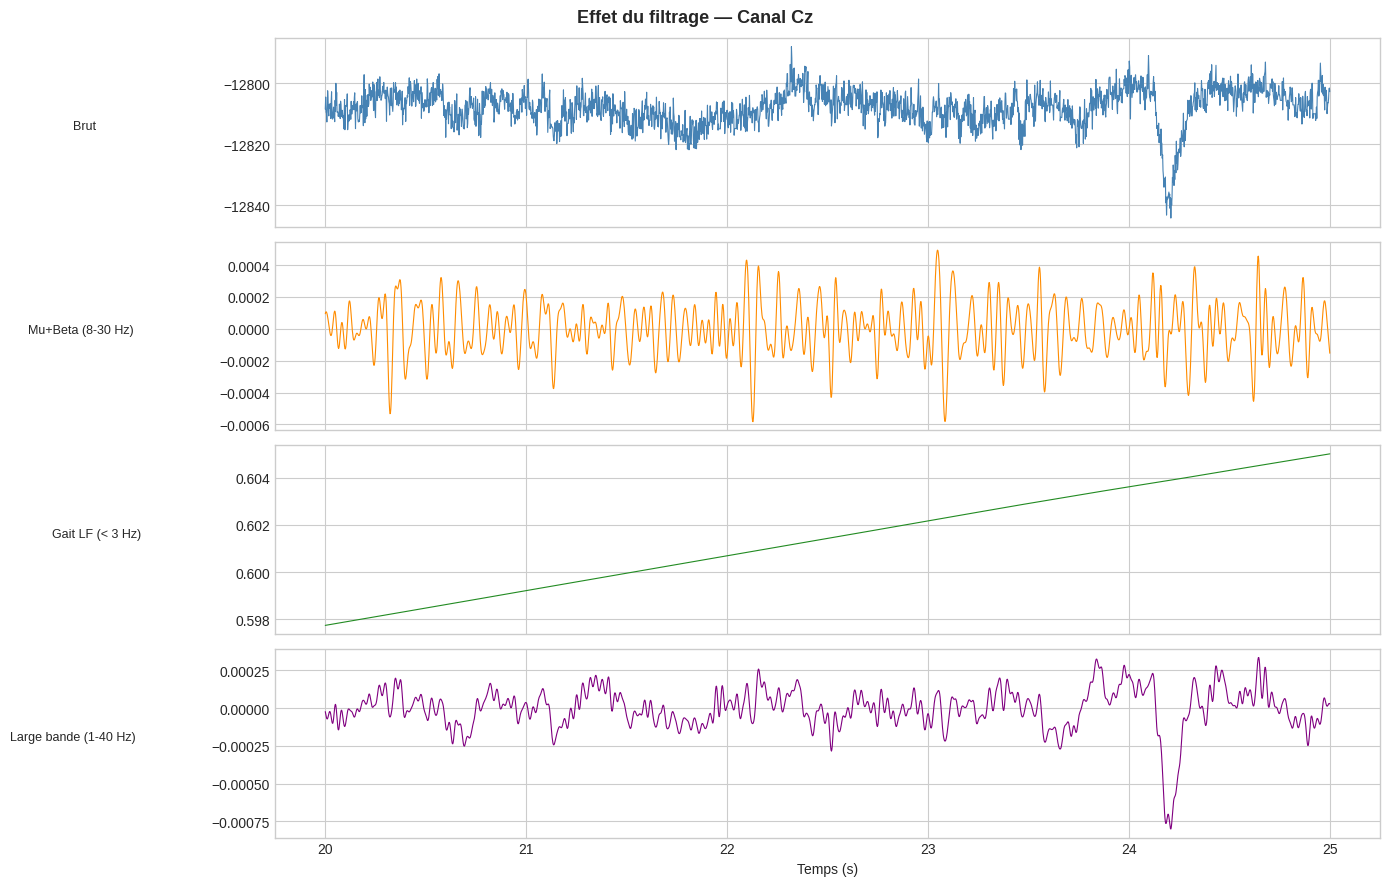

In [13]:
# ── Visualisation comparative des stratégies de filtrage ──────────────────────
ch_plot = 'Cz'
ch_idx  = EEG_CHANNELS.index(ch_plot)
t_win   = (t_all >= 20) & (t_all <= 25)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f'Effet du filtrage — Canal {ch_plot}', fontweight='bold', fontsize=13)

for ax, X_plot, label, color in [
    (axes[0], X_raw,   'Brut',                'steelblue'),
    (axes[1], X_mb,    'Mu+Beta (8-30 Hz)',    'darkorange'),
    (axes[2], X_gait,  'Gait LF (< 3 Hz)',     'forestgreen'),
    (axes[3], X_bb,    'Large bande (1-40 Hz)','purple'),
]:
    ax.plot(t_all[t_win], X_plot[t_win, ch_idx], color=color, lw=0.8)
    ax.set_ylabel(label, fontsize=9, rotation=0, labelpad=100)

axes[-1].set_xlabel('Temps (s)')
plt.tight_layout()
plt.savefig('filtering_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Feature Extraction <a id='4-features'></a>

### Adaptation pour la régression

Pour la classification (Grasp-and-Lift), on extrayait des features pour prédire un label binaire.  
Ici, on prédit une **valeur continue** (angle articulaire) à chaque instant.  

Deux approches possibles :
- **Approche fenêtres** : même logique que précédemment — features sur une fenêtre, prédiction au centre
- **Approche temporelle** : modèles séquentiels (LSTM, TCN) — hors scope ici

On conserve l'approche fenêtres glissantes, avec la même question critique : **quelle taille de fenêtre est viable en temps réel pour contrôler un exosquelette ?**

In [14]:
# ── Feature extraction par fenêtre glissante ───────────────────────────────────

def compute_band_power(x_win, fs=FS_EEG):
    """Puissance dans les bandes fréquentielles standard."""
    freqs, psd = signal.welch(x_win, fs=fs, nperseg=min(len(x_win), fs//2))
    def bp(fmin, fmax):
        idx = (freqs >= fmin) & (freqs <= fmax)
        return np.trapz(psd[idx], freqs[idx])
    return [bp(1,4), bp(4,8), bp(8,12), bp(13,30), bp(30,50)]


def extract_features_window(X_win):
    """
    Features d'une fenêtre EEG [n_samples x n_channels].
    Identique au projet Grasp-and-Lift pour comparabilité :
      - Band power  : 5 bandes × 16 canaux = 80
      - Variance    : 16
      - Covariance  : 16×17/2 = 136
    Total : 232 features
    """
    features = []
    for ch_idx in range(X_win.shape[1]):
        features.extend(compute_band_power(X_win[:, ch_idx]))
    features.extend(np.var(X_win, axis=0).tolist())
    cov = np.cov(X_win.T)
    triu = np.triu_indices(cov.shape[0])
    features.extend(cov[triu].tolist())
    return np.array(features, dtype=np.float32)


def sliding_window_regression(X, y, window_size, step_size):
    """
    Fenêtres glissantes pour la régression.
    Label = valeur IMU au centre de la fenêtre.
    """
    X_feat, y_reg = [], []
    half_win = window_size // 2
    for start in range(0, X.shape[0] - window_size, step_size):
        end    = start + window_size
        center = start + half_win
        X_feat.append(extract_features_window(X[start:end]))
        y_reg.append(y[center])
    return np.array(X_feat), np.array(y_reg)


# ── Configurations de fenêtres ─────────────────────────────────────────────────
WINDOW_CONFIGS = {
    'long_2s'   : {'window': 2*FS_EEG,    'step': FS_EEG//2,  'label': 'Fenêtre 2s   (haute précision)'},
    'medium_1s' : {'window': FS_EEG,      'step': FS_EEG//4,  'label': 'Fenêtre 1s   (compromis)'},
    'short_250ms': {'window': FS_EEG//4,  'step': FS_EEG//10, 'label': 'Fenêtre 250ms (temps-réel)'},
}

print("Configurations de fenêtres :")
for k, cfg in WINDOW_CONFIGS.items():
    latency_ms = cfg['window'] / FS_EEG * 1000
    print(f"  {cfg['label']} → latence = {latency_ms:.0f}ms")

n_features = 5*N_CHANNELS + N_CHANNELS + N_CHANNELS*(N_CHANNELS+1)//2
print(f"\nNombre de features : {n_features}")
print(f"  Band power  : {5*N_CHANNELS}")
print(f"  Variance    : {N_CHANNELS}")
print(f"  Covariance  : {N_CHANNELS*(N_CHANNELS+1)//2}")

Configurations de fenêtres :
  Fenêtre 2s   (haute précision) → latence = 2000ms
  Fenêtre 1s   (compromis) → latence = 1000ms
  Fenêtre 250ms (temps-réel) → latence = 250ms

Nombre de features : 232
  Band power  : 80
  Variance    : 16
  Covariance  : 136


In [15]:
# ── Extraction des features ────────────────────────────────────────────────────
print("Extraction des features...")
y_imu = df_labels['angle'].values

# On utilise le preprocessing broadband pour la première exploration
X_proc = preprocess_eeg(X_raw, strategy='broadband')

features_cache = {}
for config_name, cfg in WINDOW_CONFIGS.items():
    X_f, y_f = sliding_window_regression(X_proc, y_imu,
                                          window_size=cfg['window'],
                                          step_size=cfg['step'])
    features_cache[config_name] = (X_f, y_f)
    print(f"  {cfg['label']}: {X_f.shape[0]} fenêtres × {X_f.shape[1]} features")

Extraction des features...
  Fenêtre 2s   (haute précision): 5520 fenêtres × 232 features
  Fenêtre 1s   (compromis): 11043 fenêtres × 232 features
  Fenêtre 250ms (temps-réel): 27724 fenêtres × 232 features


---
## 5. Modélisation — Régression <a id='5-regression'></a>

### Métriques de régression

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| RMSE | √(mean((ŷ-y)²)) | Erreur en degrés — directement interprétable |
| R² | 1 - SS_res/SS_tot | Part de variance expliquée (1.0 = parfait) |
| Pearson r | corr(ŷ, y) | Corrélation linéaire — forme du signal |

> Pour un exosquelette, **le RMSE en degrés** est la métrique la plus cliniquement interprétable : une erreur de 5° sur l'angle de genou est-elle acceptable ? C'est une question physiologique, pas statistique.

In [16]:
# ── Modèles de régression ──────────────────────────────────────────────────────
MODELS = {
    'Ridge'          : Pipeline([('scaler', StandardScaler()),
                                  ('reg', Ridge(alpha=1.0))]),
    'Lasso'          : Pipeline([('scaler', StandardScaler()),
                                  ('reg', Lasso(alpha=0.1, max_iter=2000))]),
    'SVR (RBF)'      : Pipeline([('scaler', StandardScaler()),
                                  ('reg', SVR(kernel='rbf', C=1.0))]),
    'Random Forest'  : Pipeline([('scaler', StandardScaler()),
                                  ('reg', RandomForestRegressor(n_estimators=100,
                                                                n_jobs=-1,
                                                                random_state=42))]),
}

print("Modèles configurés :")
for name in MODELS:
    print(f"  - {name}")

Modèles configurés :
  - Ridge
  - Lasso
  - SVR (RBF)
  - Random Forest


In [17]:
# ── Benchmark performance × latence ───────────────────────────────────────────
print("Benchmark en cours...\n")
results = []

for config_name, cfg in WINDOW_CONFIGS.items():
    X_feat, y_feat = features_cache[config_name]
    window_ms = cfg['window'] / FS_EEG * 1000

    for model_name, model in MODELS.items():
        print(f"  {model_name} | {cfg['label']}...", end=' ')

        try:
            kf = KFold(n_splits=5, shuffle=False)
            rmse_scores, r2_scores, pearson_scores = [], [], []

            for train_idx, val_idx in kf.split(X_feat):
                model.fit(X_feat[train_idx], y_feat[train_idx])
                y_pred = model.predict(X_feat[val_idx])
                rmse_scores.append(np.sqrt(mean_squared_error(y_feat[val_idx], y_pred)))
                r2_scores.append(r2_score(y_feat[val_idx], y_pred))
                r, _ = pearsonr(y_feat[val_idx], y_pred)
                pearson_scores.append(r)

            # Latence d'inférence
            model.fit(X_feat[:200], y_feat[:200])
            t0 = time.perf_counter()
            for _ in range(200):
                model.predict(X_feat[:1])
            infer_ms = (time.perf_counter() - t0) / 200 * 1000

            total_latency = window_ms + infer_ms
            viable = '✅' if total_latency < 300 else ('⚠️' if total_latency < 500 else '❌')

            results.append({
                'Modèle'             : model_name,
                'Fenêtre'            : cfg['label'],
                'Window (ms)'        : window_ms,
                'RMSE (°)'           : round(np.mean(rmse_scores), 3),
                'R²'                 : round(np.mean(r2_scores), 4),
                'Pearson r'          : round(np.mean(pearson_scores), 4),
                'Inférence (ms)'     : round(infer_ms, 2),
                'Latence totale (ms)': round(total_latency, 1),
                'Viable RT'          : viable,
            })
            print(f"RMSE={np.mean(rmse_scores):.2f}° | R²={np.mean(r2_scores):.3f} "
                  f"| r={np.mean(pearson_scores):.3f} | latence={total_latency:.0f}ms {viable}")

        except Exception as e:
            print(f"ERREUR: {e}")

df_results = pd.DataFrame(results)
print("\nBenchmark terminé.")

Benchmark en cours...

  Ridge | Fenêtre 2s   (haute précision)... RMSE=3164004.03° | R²=-122537762222.798 | r=0.009 | latence=2001ms ❌
  Lasso | Fenêtre 2s   (haute précision)... RMSE=98674.95° | R²=-119156819.563 | r=0.016 | latence=2001ms ❌
  SVR (RBF) | Fenêtre 2s   (haute précision)... RMSE=14.69° | R²=-0.000 | r=0.009 | latence=2001ms ❌
  Random Forest | Fenêtre 2s   (haute précision)... RMSE=15.35° | R²=-0.104 | r=-0.010 | latence=2034ms ❌
  Ridge | Fenêtre 1s   (compromis)... RMSE=150725242.30° | R²=-275967773843711.906 | r=-0.000 | latence=1001ms ❌
  Lasso | Fenêtre 1s   (compromis)... RMSE=11544.41° | R²=-1615935.634 | r=nan | latence=1001ms ❌
  SVR (RBF) | Fenêtre 1s   (compromis)... RMSE=14.76° | R²=-0.000 | r=0.001 | latence=1001ms ❌
  Random Forest | Fenêtre 1s   (compromis)... RMSE=15.17° | R²=-0.064 | r=0.018 | latence=1036ms ❌
  Ridge | Fenêtre 250ms (temps-réel)... RMSE=3566376.00° | R²=-154217158416.536 | r=0.000 | latence=251ms ✅
  Lasso | Fenêtre 250ms (temps-réel)